## Import libraries

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

## Load Dataset

In [6]:
data = pd.read_csv('train.csv')
data.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


## Dataset info

In [7]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

In [8]:
data.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [9]:
data.shape

(1460, 81)

In [10]:
data.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

#### Clean Dataset

In [11]:
missing_values = data.isnull().sum()
missing_values = missing_values[missing_values > 0].sort_values(ascending=False)
print(missing_values)

#sorted_dic = dict(sorted(dic.items(), key=lambda item: item[1], reverse=True))
#print(sorted_dic)

data.isnull().sum()[data.isnull().sum()>0]

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64


LotFrontage      259
Alley           1369
MasVnrType       872
MasVnrArea         8
BsmtQual          37
BsmtCond          37
BsmtExposure      38
BsmtFinType1      37
BsmtFinType2      38
Electrical         1
FireplaceQu      690
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
PoolQC          1453
Fence           1179
MiscFeature     1406
dtype: int64

#### Feature Selection

In [12]:
features = ['OverallQual', 'GrLivArea', 'TotalBsmtSF','BedroomAbvGr','FullBath','GarageCars', 'YearBuilt']

x = data[features]
y = data['SalePrice'] 

## Exploratory Data Analysis

<Axes: xlabel='SalePrice', ylabel='Count'>

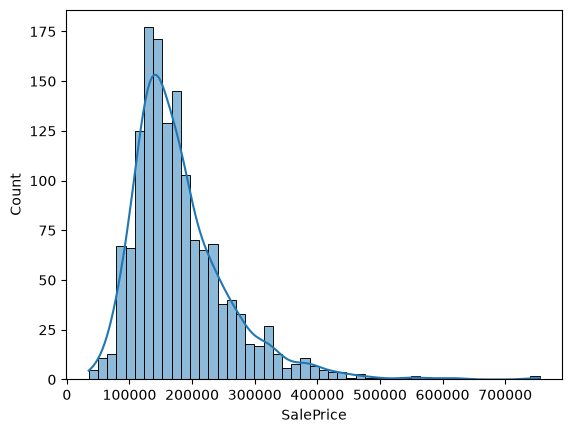

In [13]:
sns.histplot(data['SalePrice'], kde=True)

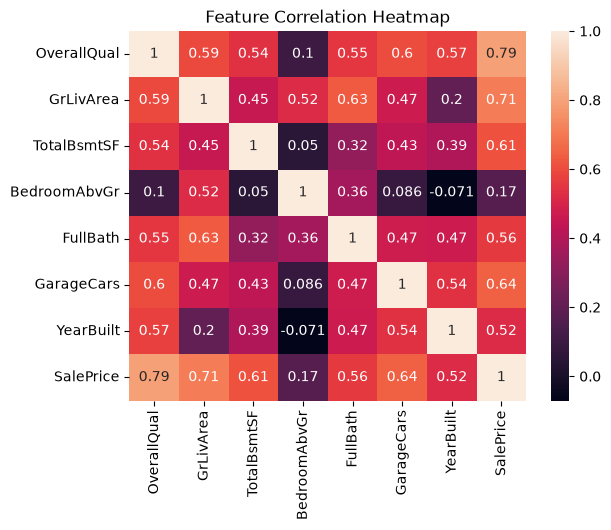

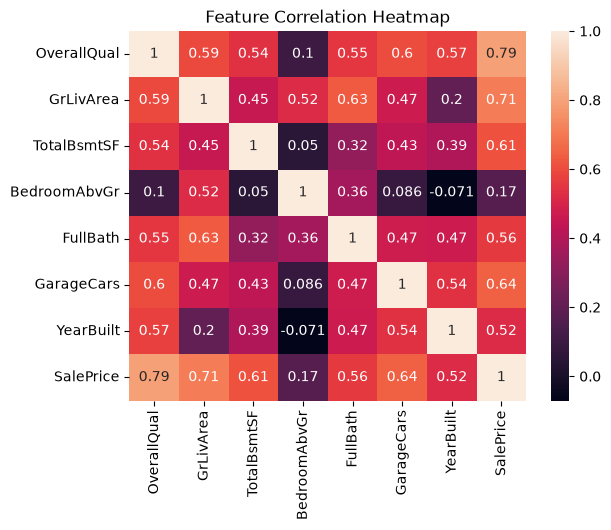

In [14]:
corr_matrix = pd.concat([x,y], axis = 1).corr()
plt.figure()
sns.heatmap(corr_matrix, annot = True)
plt.title("Feature Correlation Heatmap")
plt.show()


plt.figure()
sns.heatmap(data[features + ['SalePrice']].corr(), annot = True)
plt.title("Feature Correlation Heatmap")
plt.show()

## Train Test Split

In [15]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42) 

#### Initialize StandardScaler

In [16]:
scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

## Train MLinear Regression Model

In [17]:
model = LinearRegression()

model.fit(x_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](7,)","[26685.16,30710.72,10171.8 ,...,-1950.56,10878.51,10447.17]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1.814e+05
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,7
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(7)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](7,)","[63.51,40.12,28.81,...,22.69,20.17,14.94]"


### Model Coefficient

In [18]:
print("Coefficients = ", model.coef_)
print("Intercept = ", model.intercept_)

Coefficients =  [26685.1572566  30710.71775204 10171.80003956 -5393.80667307
 -1950.56123409 10878.50541522 10447.17492351]
Intercept =  181441.54195205483


### Make Predictions

In [19]:
y_pred = model.predict(x_test_scaled)
y_pred

array([139206.83769224, 300316.0321352 , 125307.69353873, 178537.69627366,
       290597.3898279 ,  66370.72408534, 211133.13198382, 173473.50894584,
        65689.29089821, 130389.34859453, 162623.22503368, 105521.48762557,
        93213.34573754, 221767.82885665, 196271.51415809, 118290.85150105,
       216972.67297642, 128103.75807846, 126894.39501008, 216668.45734833,
       173569.66780419, 228577.34229703, 181142.77659468, 113432.24977743,
       211985.48547492, 178176.07451819, 207278.60173882, 101031.20670654,
       190257.24127268, 214622.46986099, 113614.21603827, 254082.98780227,
       222725.47907448,  95218.60076527, 265038.36700529, 145650.14317961,
       167674.80185018, 222274.81551044, 292407.98696208,  88654.42329188,
       144745.61851598, 238907.59568713, 112982.01867507, 299180.90226027,
       127382.35678106, 159676.75336209, 114197.73202452, 111686.82122838,
       345712.96674181, 140425.47319151, 106344.38107781, 202781.78337651,
       119583.47638989, 3

## Evalution

In [20]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Mean squared error: ", mse)
print("Root mean squared error: ", rmse)
print("R2 Score: ", r2)

Mean squared error:  1520895741.6198654
Root mean squared error:  38998.66333119464
R2 Score:  0.8017169412958238


In [21]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=300, max_depth=15, random_state=42)
rf_model.fit(x_train_scaled, y_train)

y_pred_rf = rf_model.predict(x_test_scaled)

print("Random Forest R2 Score:", r2_score(y_test, y_pred_rf))

Random Forest R2 Score: 0.8925113857322972


In [22]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.05, random_state=42)
xgb_model.fit(x_train_scaled, y_train)

y_pred_xgb = xgb_model.predict(x_test_scaled)
print("XGBoost R2 Score:", r2_score(y_test, y_pred_xgb))

XGBoost R2 Score: 0.8854326605796814


In [23]:
# XGBoost Hyperparameter Tuning
xgb_tuned = XGBRegressor(
    n_estimators=300,
    learning_rate=0.03,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_tuned.fit(x_train_scaled, y_train)
y_pred_tuned = xgb_tuned.predict(x_test_scaled)

print("Tuned XGBoost R2 Score:", r2_score(y_test, y_pred_tuned))

Tuned XGBoost R2 Score: 0.9049038290977478


In [24]:
# Example for Regression / Classification
train_score = xgb_tuned.score(x_train_scaled, y_train)
test_score = xgb_tuned.score(x_test_scaled, y_test)

print(f"Train Score: {train_score}")
print(f"Test Score: {test_score}")

if train_score - test_score > 0.10: # 10% ku mela gap irundha
    print("Overfitting happens!")

Train Score: 0.9384011030197144
Test Score: 0.9049038290977478


## EVALUTION for tunned XGBoost

In [25]:
mse = mean_squared_error(y_test, y_pred_tuned)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_tuned)

print("Mean squared error: ", mse)
print("Root mean squared error: ", rmse)
print("R2 Score: ", r2)

Mean squared error:  729418752.0
Root mean squared error:  27007.753553377963
R2 Score:  0.9049038290977478


In [26]:
from sklearn.model_selection import cross_val_score
# Tuned XGBoost-ku CV Mean Score paaka:
xgb_cv_scores = cross_val_score(xgb_tuned, x, y, cv=5)
print("XGBoost CV Mean Score:", xgb_cv_scores.mean())

XGBoost CV Mean Score: 0.8553915858268738


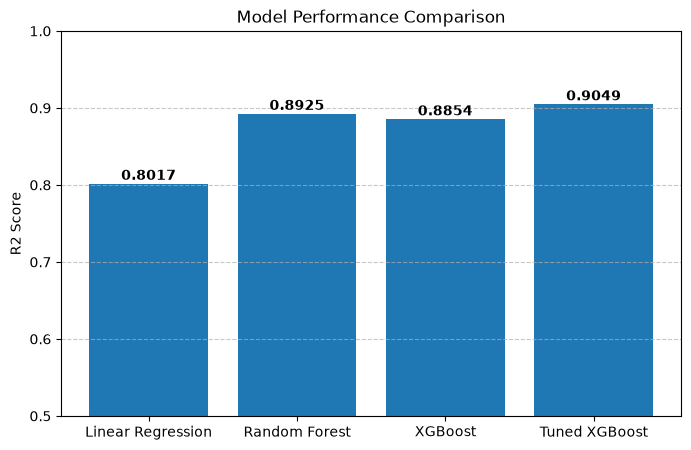

In [27]:


models = ['Linear Regression', 'Random Forest', 'XGBoost', 'Tuned XGBoost']
scores = [0.8017, 0.8925, 0.8854, 0.9049]

plt.figure(figsize=(8, 5))
plt.bar(models, scores)
plt.ylim(0.5, 1.0)
plt.ylabel('R2 Score')
plt.title('Model Performance Comparison')
plt.grid(axis='y', linestyle='--', alpha=0.7)

for i, score in enumerate(scores):
    plt.text(i, score + 0.005, f"{score}", ha='center', weight='bold')

plt.show()